In [2]:
from rdkit import Chem
import pandas as pd
from rdkit.Chem import MolStandardize

def standardize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # удаление солей
    mol = MolStandardize.rdMolStandardize.FragmentParent(mol)
    
    # нормализация
    mol = MolStandardize.rdMolStandardize.Cleanup(mol)
    
    return Chem.MolToSmiles(mol, isomericSmiles=False)

def prepare_dataset(df):

    # 1. фильтрация
    df = df.dropna(subset=["PUBCHEM_EXT_DATASOURCE_SMILES", "Log of AC50"])
    df = df[df["Curve R2"] > 0.7]
    df = df[df["Curve Class"].isin([1,2,3])]
    
    # 2. стандартизация
    df["smiles"] = df["PUBCHEM_EXT_DATASOURCE_SMILES"].apply(standardize)
    # df = df.dropna(subset=["smiles"])
    
    # 3. target
    df["activity"] = df["Log of AC50"]

    return df



df = pd.read_csv("dataset/AID_585_datatable_all.csv")
df.drop(index=[0, 1, 2], inplace=True)
df.drop(columns=["PUBCHEM_RESULT_TAG", "PUBCHEM_ACTIVITY_URL", "PUBCHEM_ASSAYDATA_COMMENT", "Curve Description"], inplace=True)
df.reset_index(drop=True, inplace=True)

df.to_csv("dataset/AID_585_datatable_all_cleaned.csv", index=False)
df = pd.read_csv("dataset/AID_585_datatable_all_cleaned.csv")

df = prepare_dataset(df)
df.to_csv("dataset/AID_585_datatable_preprocessed.csv", index=False)
df = pd.read_csv("dataset/AID_585_datatable_preprocessed.csv")
df.head()


C:\Users\Mikhail\AppData\Local\Temp\ipykernel_9128\1074141873.py:36: DtypeWarning: Columns (0,10,11,12,13,14,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset/AID_585_datatable_all.csv")
[23:23:27] Initializing MetalDisconnector
[23:23:27] Running MetalDisconnector
[23:23:27] Initializing Normalizer
[23:23:27] Running Normalizer
[23:23:27] Running LargestFragmentChooser
[23:23:27] Initializing MetalDisconnector
[23:23:27] Running MetalDisconnector
[23:23:27] Initializing Normalizer
[23:23:27] Running Normalizer
[23:23:27] Initializing MetalDisconnector
[23:23:27] Running MetalDisconnector
[23:23:27] Initializing Normalizer
[23:23:27] Running Normalizer
[23:23:27] Running LargestFragmentChooser
[23:23:27] Initializing MetalDisconnector
[23:23:27] Running MetalDisconnector
[23:23:27] Initializing Normalizer
[23:23:27] Running Normalizer
[23:23:27] Initializing MetalDisconnector
[23:23:27]

,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_ACTIVITY_SCORE,Activity Direction,Log of AC50,Hill Coefficient,Curve R2,Curve Infinite Activity,...,Activity at 0.23uM,Activity at 0.15uM,Activity at 1.15uM,Activity at 2.57uM,Activity at 5.75uM,Activity at 12.85uM,Activity at 28.73uM,Compound Type,smiles,activity
0,7967356.0,5308778.0,CN1C2=C(C=C(S2)C(=O)N3CCOCC3)C(=N1)C4=CC=C(C=C...,Inactive,0.0,Increasing,-4.8,4.50,0.99,159.6,...,-5.4,NaN,5.5,NaN,-2.4,NaN,149.1,qHTS ECL - DPISMR,Cn1nc(-c2ccc(Cl)cc2)c2cc(C(=O)N3CCOCC3)sc21,-4.8
1,7965808.0,5307848.0,CN1C2=C(C=C(S2)C(=O)NCC3CCCO3)C(=N1)C4=CC=C(C=...,Inactive,0.0,Increasing,-4.8,4.95,0.98,157.0,...,5.2,NaN,12.8,NaN,-4.3,NaN,149.5,qHTS ECL - DPISMR,Cn1nc(-c2ccc(Cl)cc2)c2cc(C(=O)NCC3CCCO3)sc21,-4.8
2,4240002.0,3235109.0,C1CN(CCN1)C2=NC=C3C(=N2)N(C(=O)C(=N3)CCC4=CC=C...,Inactive,0.0,Increasing,-4.8,4.95,0.99,153.1,...,0.2,NaN,-0.4,NaN,-1.3,NaN,145.2,qHTS ECL - Pharmacopeia,O=c1c(CCc2ccccc2)nc2cnc(N3CCNCC3)nc2n1Cc1ccc(F...,-4.8
3,853631.0,656289.0,COC1=C(C=CC(=C1)C2=NN=C(O2)C3=CC=NC=C3)OCC4=CC...,Inactive,0.0,Increasing,-4.9,4.09,1.00,152.4,...,5.3,NaN,4.4,NaN,9.5,NaN,147.5,qHTS ECL - MLSMR,COc1cc(-c2nnc(-c3ccncc3)o2)ccc1OCc1ccccc1,-4.9
4,7966511.0,5308280.0,CCOC(=O)C1=C(N(C(=C1C)C2=CC=CC=C2)CC(=O)N3CCN(...,Inactive,0.0,Increasing,-4.8,4.95,0.97,150.6,...,-1.5,NaN,26.8,NaN,9.0,NaN,143.8,qHTS ECL - DPISMR,CCOC(=O)c1c(C)c(-c2ccccc2)n(CC(=O)N2CCN(C)CC2)c1C,-4.8


In [3]:
from optunaz.utils.preprocessing.deduplicator import *

df = pd.read_csv("dataset/AID_585_datatable_preprocessed.csv")
primarydf = df[["smiles", "activity"]]
primarydf.to_csv("dataset/AID_585_datatable_smiles_activity.csv", index=False)
primarydf = pd.read_csv("dataset/AID_585_datatable_smiles_activity.csv")

col = "smiles"

df_pos = KeepFirst().dedup(primarydf, col)
df_rnd = KeepRandom().dedup(primarydf, col)
df_max = KeepMax().dedup(primarydf, col)
df_avg = KeepAvg().dedup(primarydf, col)
df_med = KeepMedian().dedup(primarydf, col)

# print sizes
print(f"original: {len(primarydf)}, deduplidcated: {len(df_pos)}, {len(df_rnd)}, {len(df_max)}, {len(df_avg)}, {len(df_med)}")

original: 4823, deduplidcated: 4823, 4823, 4823, 4823, 4823


In [4]:
idx = primarydf.duplicated(subset='smiles')
print(primarydf[idx])

Empty DataFrame
Columns: [smiles, activity]
Index: []


In [5]:
primarydf

,smiles,activity
0,Cn1nc(-c2ccc(Cl)cc2)c2cc(C(=O)N3CCOCC3)sc21,-4.8
1,Cn1nc(-c2ccc(Cl)cc2)c2cc(C(=O)NCC3CCCO3)sc21,-4.8
2,O=c1c(CCc2ccccc2)nc2cnc(N3CCNCC3)nc2n1Cc1ccc(F...,-4.8
3,COc1cc(-c2nnc(-c3ccncc3)o2)ccc1OCc1ccccc1,-4.9
4,CCOC(=O)c1c(C)c(-c2ccccc2)n(CC(=O)N2CCN(C)CC2)c1C,-4.8
...,...,...
4818,CCOc1ccc(-n2c(Cc3cc(=O)[nH]c(=O)[nH]3)nnc2SCC(...,-5.2
4819,Cn1c(C(=O)N2CCCCCC2)cc2c(=O)n(C)c3ccccc3c21,-5.5
4820,CCc1nnc(NC(=O)C2CCN(c3nccc(C)n3)CC2)s1,-4.8
4821,CC1=Nc2ccc(C)cc2N(Cc2ccccc2)C(=O)C1,-5.7


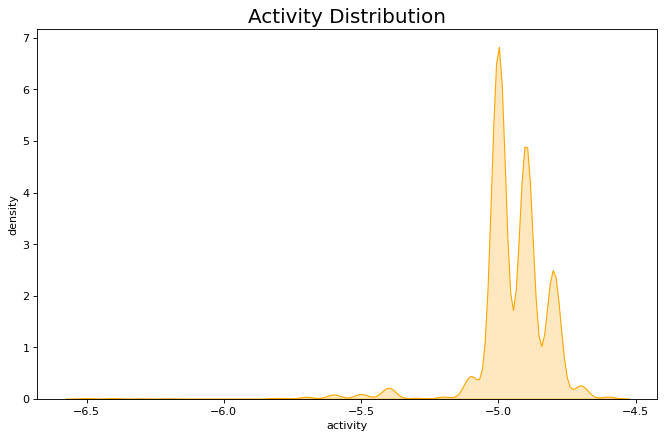

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6), dpi=80)

plt.xlabel("activity")
plt.ylabel("density")
plt.title("Activity Distribution", fontsize=18)

sns.kdeplot(primarydf["activity"], fill=True, color="orange", alpha=0.25)
plt.show()

In [7]:
%run ../QSARtuna/optunaz/utils/preprocessing/splitter.py

train_str, test_str = Stratified(fraction=0.2, seed=42, bins="fd").split(primarydf["smiles"], primarydf["activity"])

print("Train (stratified):", len(train_str))
print("Test (stratified):", len(test_str))

Train (stratified): 3858
Test (stratified): 965


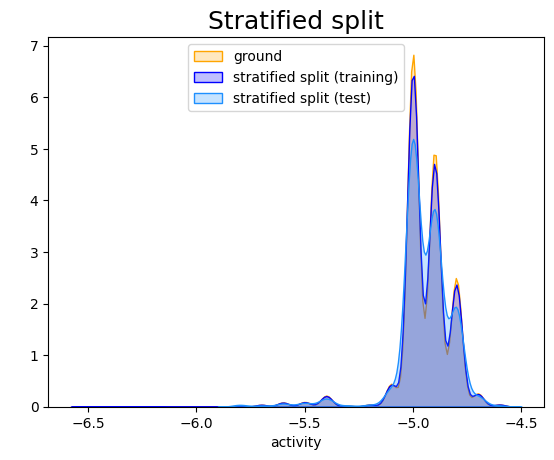

In [8]:
plt.xlabel("activity")
plt.ylabel(" ")
plt.title("Stratified split", fontsize=18)
sns.kdeplot(primarydf["activity"], fill=True, color="orange", label="ground", alpha=0.25)
sns.kdeplot(primarydf.loc[train_str]["activity"], fill=True, color="blue", label="stratified split (training)", alpha=0.25)
sns.kdeplot(primarydf.loc[test_str]["activity"], fill=True, color="dodgerblue", label="stratified split (test)", alpha=0.25)
plt.legend(loc="upper center")

In [10]:
primarydf.loc[train_str].to_csv("dataset/AID_585_train_str.csv", index=False)
primarydf.loc[test_str].to_csv("dataset/AID_585_test_str.csv", index=False)